In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

In [2]:
f = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/dihiggs_output_13TeV.root"
file = uproot.open(f)
print("Available keys:", file.keys())
tree_h = file["Delphes"]
f_qcd = uproot.open("/home/sawini-jana/hep/MG5_aMC_v3_7_1/qcd_output_13TeV.root")
tree_qcd = f_qcd["Delphes"]
print("Available keys:", f_qcd.keys())

Available keys: ['ProcessID0;1', 'Delphes;1']
Available keys: ['ProcessID0;1', 'Delphes;1']


In [3]:
branches = file['Delphes'].keys()
print(len(branches))

455


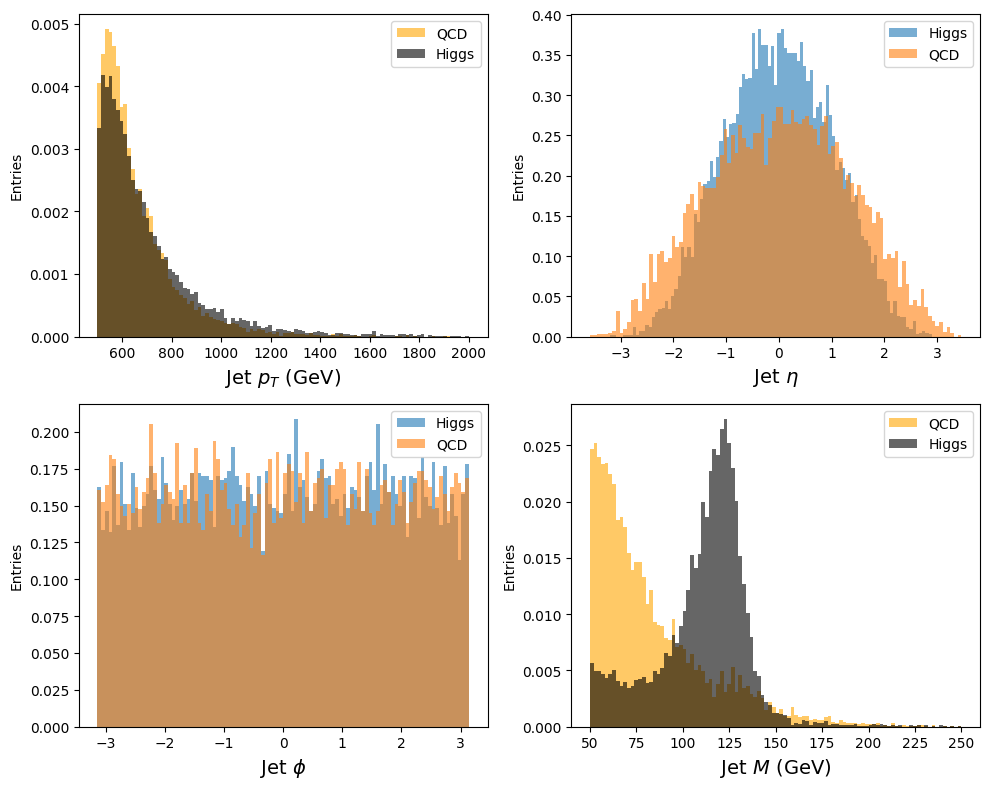

In [4]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["Jet.PT"].array()
    eta  = tree["Jet.Eta"].array()
    phi  = tree["Jet.Phi"].array()
    mass = tree["Jet.Mass"].array()
    tau  = tree["Jet.Tau[5]"].array()
    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi, tau = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet], tau[has_jet]
    
    tau1, tau2, tau3, tau4 = ak.to_numpy(tau[:,0,0]), ak.to_numpy(tau[:,0,1]), ak.to_numpy(tau[:,0,2]), ak.to_numpy(tau[:,0,3])
    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    tau21 = np.full_like(tau1, -1.0, dtype=float)
    np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
    tau32 = np.full_like(tau2, -1.0, dtype=float)
    np.divide(tau3, tau2, out=tau32, where=tau2 > 0)
    tau43 = np.full_like(tau3, -1.0, dtype=float)
    np.divide(tau4, tau3, out=tau43, where=tau3 > 0)
    
    return lead_pt, lead_mass, lead_eta, lead_phi, tau21, tau32, tau43

jet_pt,  jet_mass, jet_eta, jet_phi , jet_tau21, jet_tau32, jet_tau43 = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd, jet_tau21_qcd, jet_tau32_qcd, jet_tau43_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'Jet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'Jet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'Jet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,250), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 250), color = "black")
axes[1,1].set_xlabel(r'Jet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

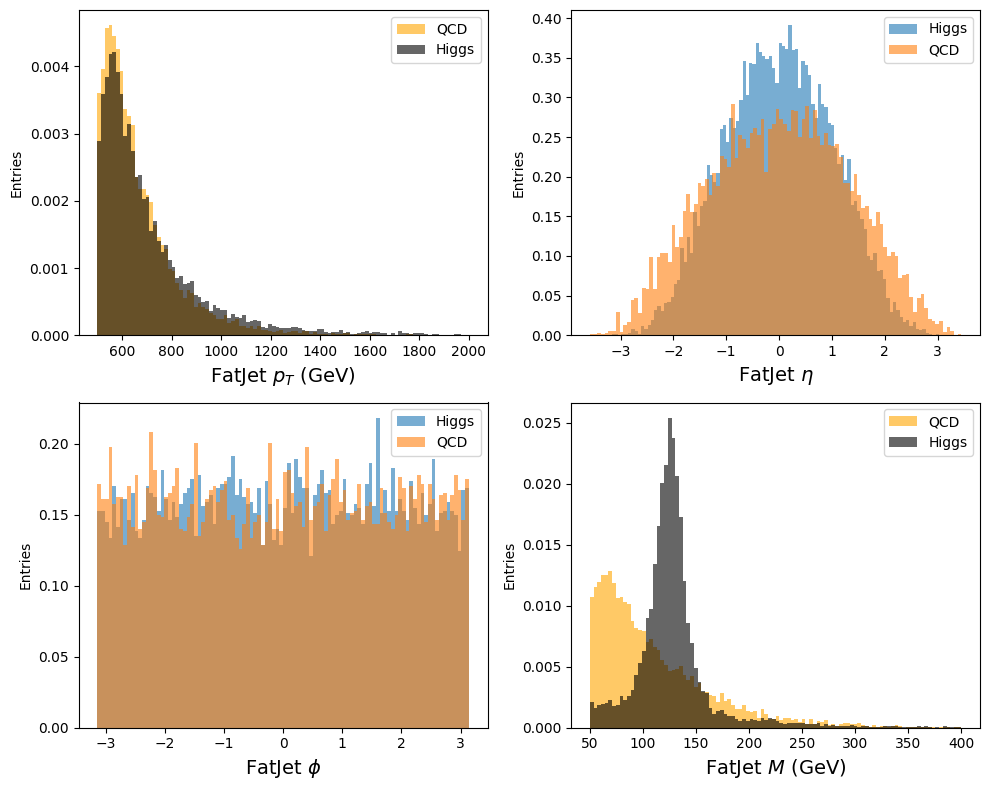

In [16]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["FatJet.PT"].array()
    eta  = tree["FatJet.Eta"].array()
    phi  = tree["FatJet.Phi"].array()
    mass = tree["FatJet.Mass"].array()
    tau  = tree["FatJet.Tau[5]"].array()
    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi, tau = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet], tau[has_jet]
    
    tau1, tau2, tau3, tau4 = ak.to_numpy(tau[:,0,0]), ak.to_numpy(tau[:,0,1]), ak.to_numpy(tau[:,0,2]), ak.to_numpy(tau[:,0,3])
    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    tau21 = np.full_like(tau1, -1.0, dtype=float)
    np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
    tau32 = np.full_like(tau2, -1.0, dtype=float)
    np.divide(tau3, tau2, out=tau32, where=tau2 > 0)
    tau43 = np.full_like(tau3, -1.0, dtype=float)
    np.divide(tau4, tau3, out=tau43, where=tau3 > 0)

    return lead_pt, lead_mass, lead_eta, lead_phi, tau21, tau32, tau43


jet_pt,  jet_mass, jet_eta, jet_phi , fat_jet_tau21, jet_tau32, jet_tau43 = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd, fatjet_tau21_qcd, jet_tau32_qcd, jet_tau43_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'FatJet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'FatJet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'FatJet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,400), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 400), color = "black")
axes[1,1].set_xlabel(r'FatJet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

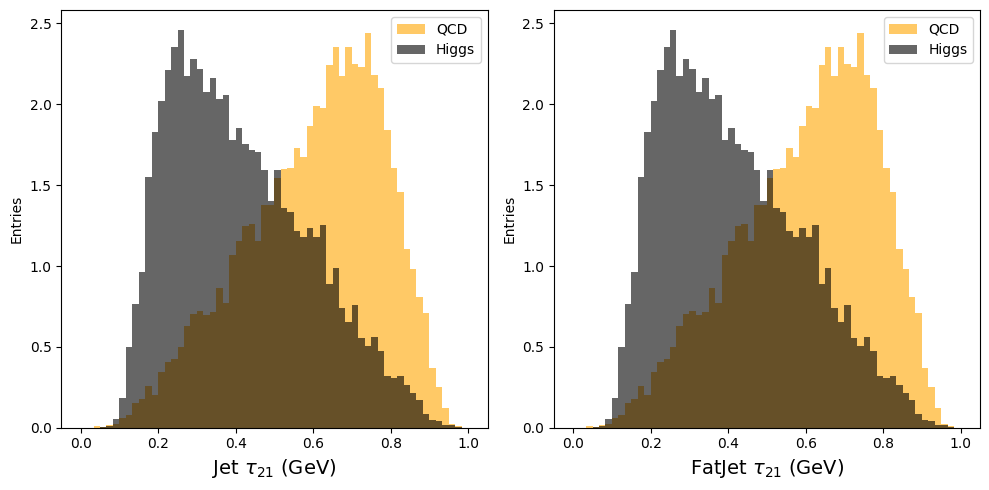

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(jet_tau21_qcd,bins=60, label = "QCD", density="True", alpha=0.6, color = "orange", range=(0,1))
axes[0].hist(jet_tau21,bins=60, label = "Higgs", density="True", alpha=0.6,color = "Black", range=(0,1))
axes[0].set_xlabel(r'Jet ${\tau}_{21}$ (GeV)',fontsize=14)
axes[0].set_ylabel("Entries")
axes[0].legend()

axes[1].hist(fatjet_tau21_qcd,bins=60, label = "QCD", density="True", alpha=0.6, color = "orange",range=(0,1))
axes[1].hist(fat_jet_tau21,bins=60, label = "Higgs", density="True", alpha=0.6,color = "Black",range=(0,1))
axes[1].set_xlabel(r'FatJet ${\tau}_{21}$ (GeV)',fontsize=14)
axes[1].set_ylabel("Entries")
axes[1].legend()

plt.tight_layout()
plt.show()

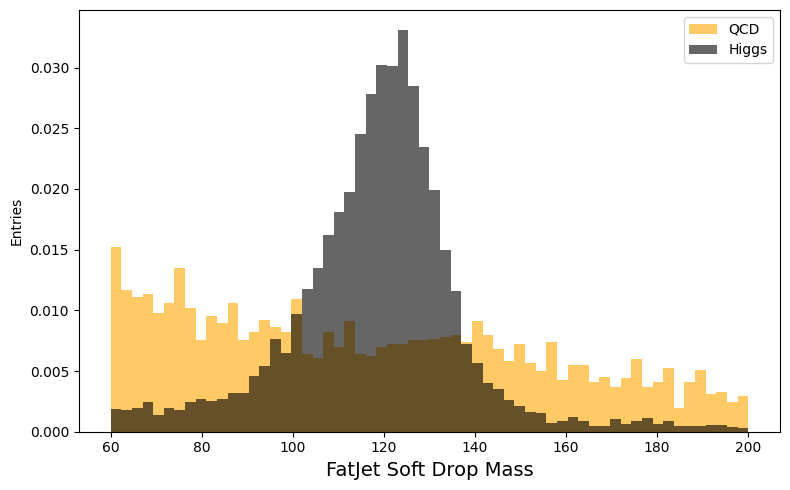

In [42]:
fat_p4 = tree_h["FatJet.SoftDroppedP4[5]"].array()
fat_p4_qcd = tree_qcd["FatJet.SoftDroppedP4[5]"].array()

fatmass_h = np.zeros(len(fat_p4))
fatmass_qcd = np.zeros(len(fat_p4_qcd))

m_list = [fatmass_h, fatmass_qcd]
p4_list = [fat_p4,fat_p4_qcd]

for j in range(len(m_list)):
    for i in range(len(p4_list[j])):
        if len(fat_p4_qcd[i]) > 0:
            v = p4_list[j][i,0,0]
        else:
            continue
        l = v.fE**2 - v.fP.fX**2 - v.fP.fY**2 - v.fP.fZ**2
        if l > 0:
            m2 = np.sqrt(l)
            m_list[j][i] = m2


plt.figure(figsize=(8, 5))
plt.hist(fatmass_qcd,bins=60, label = "QCD", density="True", alpha=0.6, color = "orange", range=(60,200))
plt.hist(fatmass_h,bins=60, label = "Higgs", density="True", alpha=0.6,color = "Black", range=(60, 200))
plt.xlabel(r'FatJet Soft Drop Mass',fontsize=14)
plt.ylabel("Entries")
plt.legend()
plt.tight_layout()
plt.show()

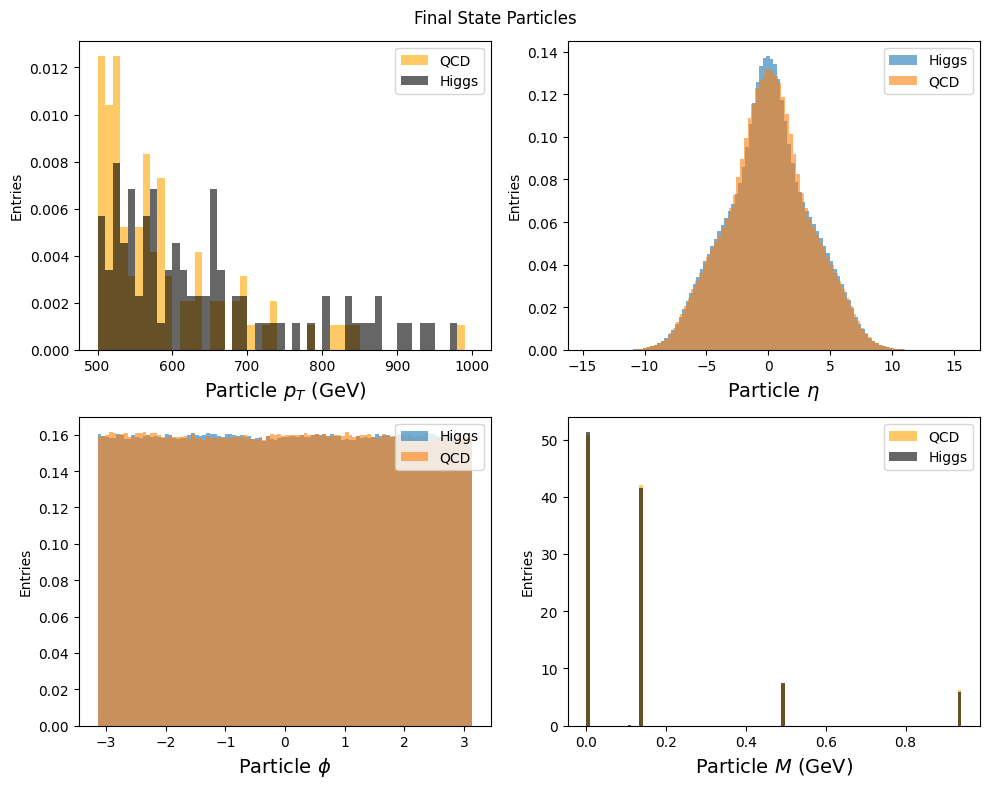

In [9]:
# %%
def get_leading_jet_obs(tree):
    pt   = ak.flatten(tree["Particle.PT"].array())
    eta  = ak.flatten(tree["Particle.Eta"].array())
    phi  = ak.flatten(tree["Particle.Phi"].array())
    mass = ak.flatten(tree["Particle.Mass"].array())

    # keep only events with at least one FatJet
    has_jet = (ak.flatten(tree["Particle.Status"] .array()) == 1) & (pt>0)
    final_pt, final_mass, final_eta, final_phi = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet]

    return final_pt, final_mass, final_eta, final_phi

part_pt,  part_mass, part_eta, part_phi = get_leading_jet_obs(tree_h)
part_pt_qcd, part_mass_qcd, part_eta_qcd, part_phi_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Final State Particles")

axes[0,0].hist(part_pt_qcd,bins=50, label = "QCD", density=True, alpha=0.6, color = "orange", range=(500,1000))
axes[0,0].hist(part_pt,bins=50, label = "Higgs", density=True, alpha=0.6,color = "Black",range=(500,1000))
axes[0,0].set_xlabel(r'Particle $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(part_eta,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[0,1].hist(part_eta_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[0,1].set_xlabel(r'Particle ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(part_phi,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[1,0].hist(part_phi_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[1,0].set_xlabel(r'Particle ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(part_mass_qcd,bins=100, label = "QCD", density=True, alpha=0.6, color="orange")
axes[1,1].hist(part_mass,bins=100, label = "Higgs", density=True, alpha=0.6, color = "black")
axes[1,1].set_xlabel(r'Particle $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Observable Analysis

In [10]:
import pandas as pd

file = open("/home/sawini-jana/hep/pythia8316/coding/observables_13TeV.csv", "r", newline='')
df = pd.read_csv(file)

print(df['phi1'][0:5] + 1)
print(df.loc[10:12]['phi2'])

higgs = df[df.label==1][['phi1', 'phi2', 'phi3', 'phi4']].values
qcd = df[df.label==0][['phi1', 'phi2', 'phi3', 'phi4']].values
print(higgs)

0    1.028109
1    1.047429
2    1.046917
3    1.030987
4    1.104287
Name: phi1, dtype: float64
10    0.150647
11    0.269225
12    0.309512
Name: phi2, dtype: float64
[[0.0281094  0.20518    0.140205   0.00410879]
 [0.0474287  0.326524   0.185428   0.00629361]
 [0.0469169  0.265522   0.112446   0.0012264 ]
 ...
 [0.0432711  0.291572   0.108096   0.00153577]
 [0.137169   0.174138   0.157263   0.00429189]
 [0.0728299  0.229351   0.182236   0.00710803]]


In [11]:
qcd = qcd[int(len(qcd)/4):int(3*len(qcd)/4)]
print(len(higgs)+len(qcd))
print(len(qcd)/len(higgs)) #25:75 ratio

2353
0.7546607009694258


In [12]:
import numpy as np

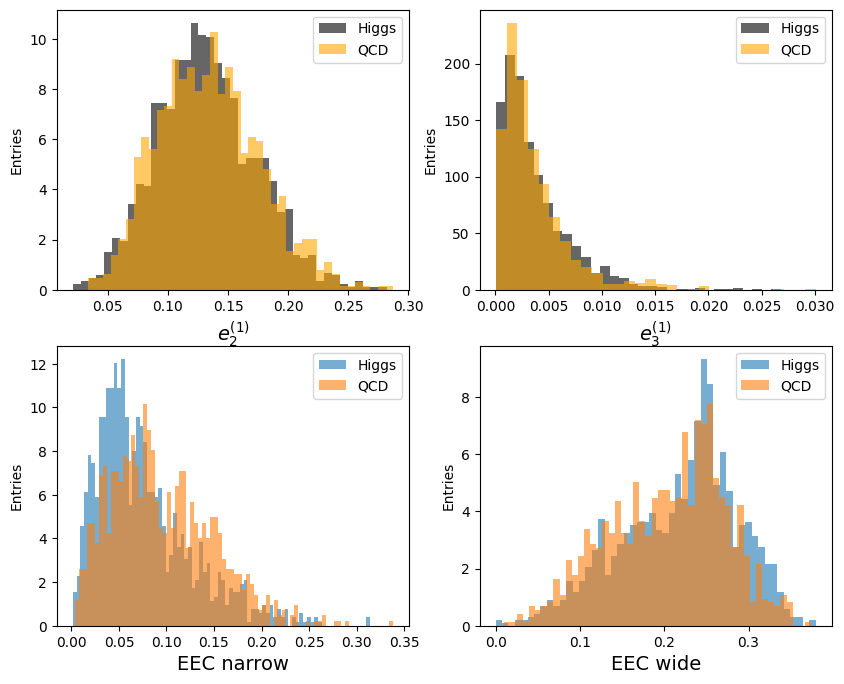

In [13]:
import matplotlib.pyplot as plt

#HIGGS
EECnarrow_h = higgs[:,0]
EECwide_h = higgs[:,1]
ecf2_h = higgs[:,2]
ecf3_h = higgs[:,3]

#QCD
EECnarrow_qcd = qcd[:,0]
EECwide_qcd = qcd[:,1]
ecf2_qcd = qcd[:,2]
ecf3_qcd = qcd[:,3]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(ecf2_h, bins=40, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,0].hist(ecf2_qcd, bins=40, density=True, alpha=0.6, label="QCD", color="orange")
axes[0,0].set_xlabel(r'$e_2^{(1)}$',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(ecf3_h, bins=30, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,1].hist(ecf3_qcd, bins=30, density=True, alpha=0.6, label="QCD", color ="orange")
axes[0,1].set_xlabel(r'$e_3^{(1)}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(EECnarrow_h, bins=80, density=True, alpha=0.6, label="Higgs")
axes[1,0].hist(EECnarrow_qcd, bins=80, density=True, alpha=0.6, label="QCD")
axes[1,0].set_xlabel(r'EEC narrow',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(EECwide_h, bins=50, density=True, alpha=0.6, label="Higgs")
axes[1,1].hist(EECwide_qcd, bins=50, density=True, alpha=0.6, label="QCD")
axes[1,1].set_xlabel(r'EEC wide',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.show()

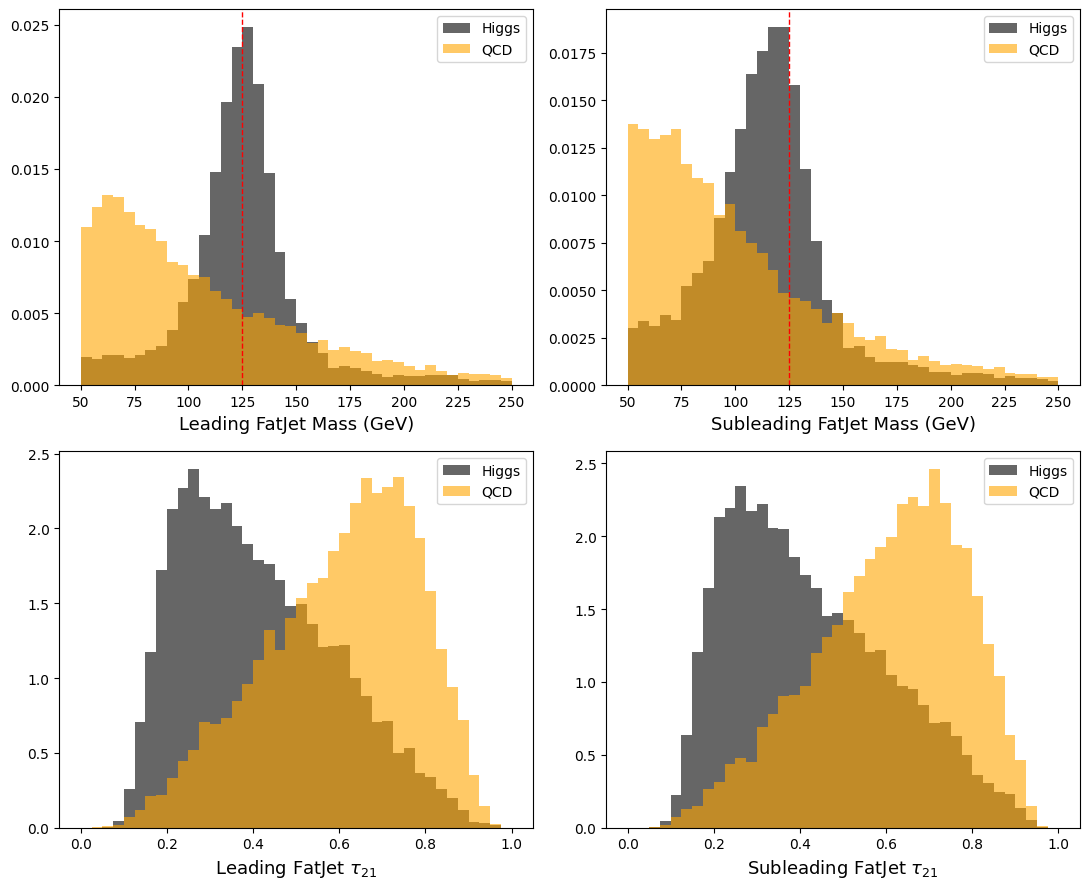

In [15]:
# %% [markdown]
# ### Check 2: Extract BOTH leading FatJets per event, not just one

# %%
def get_two_leading_fatjets(tree):
    pt   = tree["FatJet.PT"].array()
    eta  = tree["FatJet.Eta"].array()
    phi  = tree["FatJet.Phi"].array()
    mass = tree["FatJet.Mass"].array()
    tau  = tree["FatJet.Tau[5]"].array()

    has_two = ak.num(pt) >= 2   # require at least 2 FatJets this time
    pt, eta, phi, mass, tau = pt[has_two], eta[has_two], phi[has_two], mass[has_two], tau[has_two]

    # leading (index 0) and subleading (index 1) FatJet observables
    lead_pt,   sub_pt   = ak.to_numpy(pt[:,0]),   ak.to_numpy(pt[:,1])
    lead_mass, sub_mass = ak.to_numpy(mass[:,0]), ak.to_numpy(mass[:,1])

    lead_tau1, lead_tau2 = ak.to_numpy(tau[:,0,0]), ak.to_numpy(tau[:,0,1])
    sub_tau1,  sub_tau2  = ak.to_numpy(tau[:,1,0]), ak.to_numpy(tau[:,1,1])

    with np.errstate(divide='ignore', invalid='ignore'):
        lead_tau21 = np.where(lead_tau1 > 0, lead_tau2/lead_tau1, -1)
        sub_tau21  = np.where(sub_tau1  > 0, sub_tau2/sub_tau1,  -1)

    return (lead_pt, lead_mass, lead_tau21), (sub_pt, sub_mass, sub_tau21)

(lead_h, sub_h) = get_two_leading_fatjets(tree_h)
(lead_qcd, sub_qcd) = get_two_leading_fatjets(tree_qcd)

lead_pt_h, lead_mass_h, lead_tau21_h = lead_h
sub_pt_h,  sub_mass_h,  sub_tau21_h  = sub_h
lead_pt_qcd, lead_mass_qcd, lead_tau21_qcd = lead_qcd
sub_pt_qcd,  sub_mass_qcd,  sub_tau21_qcd  = sub_qcd

# %%
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0,0].hist(lead_mass_h,   bins=40, range=(50,250), density=True, alpha=0.6, label="Higgs", color="black")
axes[0,0].hist(lead_mass_qcd, bins=40, range=(50,250), density=True, alpha=0.6, label="QCD",   color="orange")
axes[0,0].axvline(125, color='red', ls='--', lw=1)
axes[0,0].set_xlabel("Leading FatJet Mass (GeV)", fontsize=13)
axes[0,0].legend()

axes[0,1].hist(sub_mass_h,   bins=40, range=(50,250), density=True, alpha=0.6, label="Higgs", color="black")
axes[0,1].hist(sub_mass_qcd, bins=40, range=(50,250), density=True, alpha=0.6, label="QCD",   color="orange")
axes[0,1].axvline(125, color='red', ls='--', lw=1)
axes[0,1].set_xlabel("Subleading FatJet Mass (GeV)", fontsize=13)
axes[0,1].legend()

axes[1,0].hist(lead_tau21_h,   bins=40, range=(0,1), density=True, alpha=0.6, label="Higgs", color="black")
axes[1,0].hist(lead_tau21_qcd, bins=40, range=(0,1), density=True, alpha=0.6, label="QCD",   color="orange")
axes[1,0].set_xlabel(r"Leading FatJet $\tau_{21}$", fontsize=13)
axes[1,0].legend()

axes[1,1].hist(sub_tau21_h,   bins=40, range=(0,1), density=True, alpha=0.6, label="Higgs", color="black")
axes[1,1].hist(sub_tau21_qcd, bins=40, range=(0,1), density=True, alpha=0.6, label="QCD",   color="orange")
axes[1,1].set_xlabel(r"Subleading FatJet $\tau_{21}$", fontsize=13)
axes[1,1].legend()

plt.tight_layout()
plt.show()